In [129]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np


# Verisetlerini yükle

df = pd.read_csv('test_regresyon.csv', encoding='utf-8')


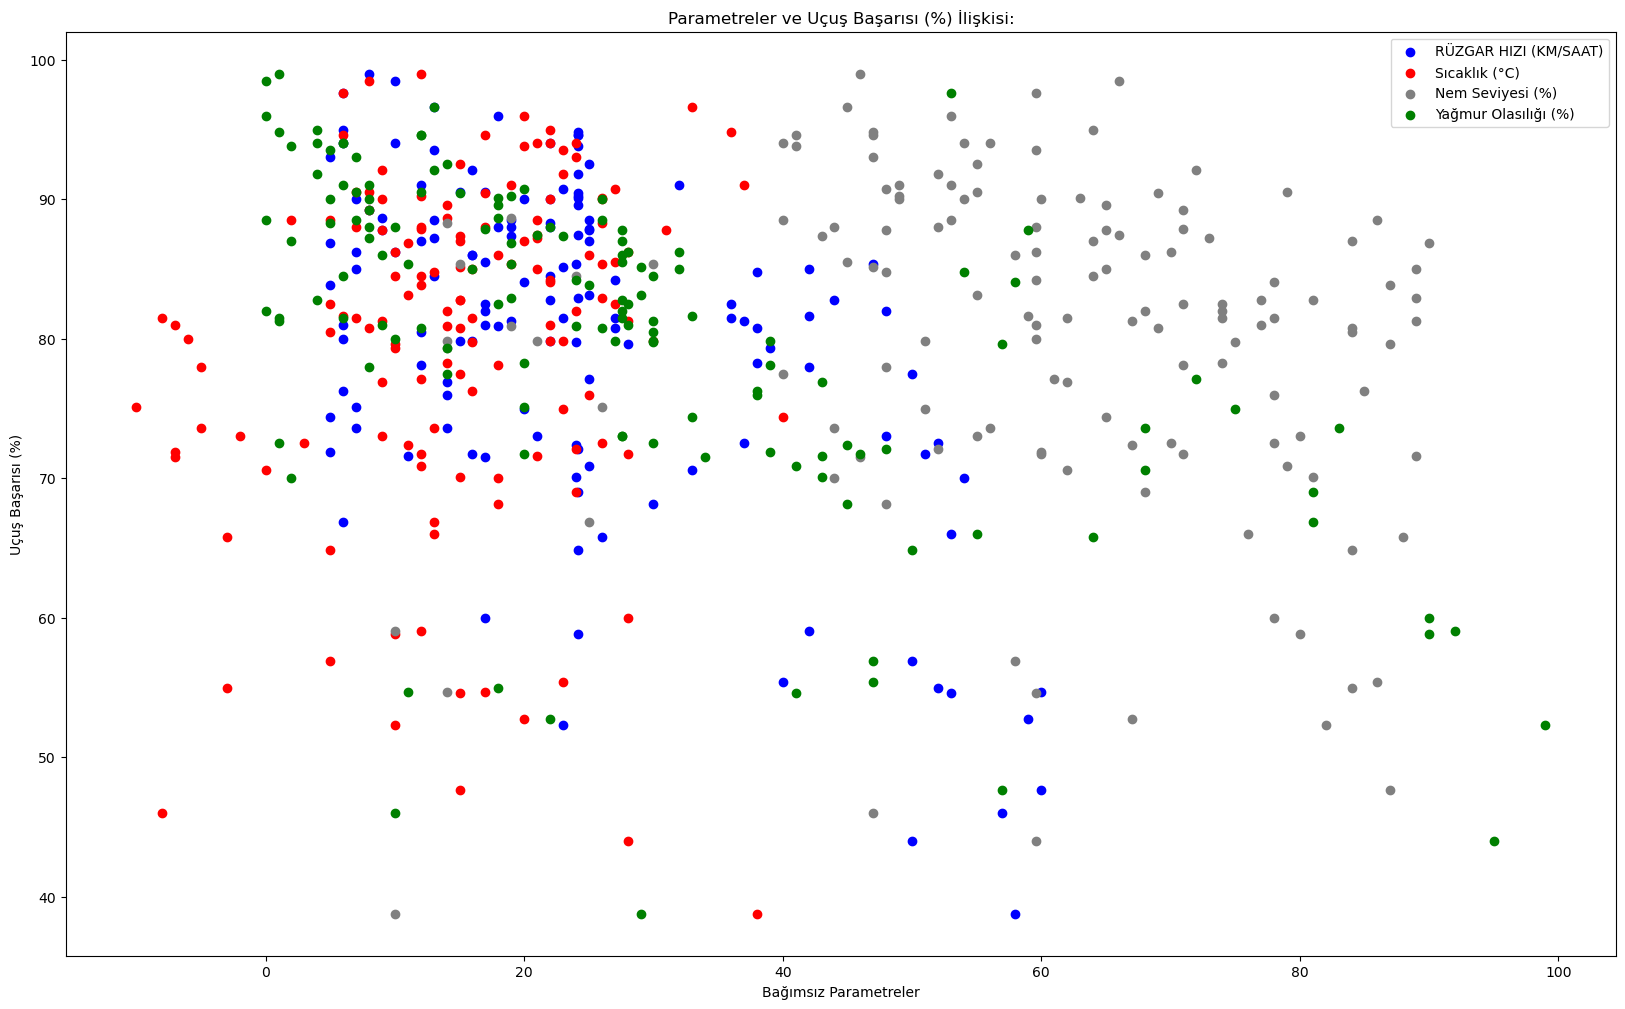

In [130]:
plt.figure(figsize=(20, 12))
plt.scatter(df['RÜZGAR HIZI (KM/SAAT)'], df['Uçuş Başarısı (%)'], label='RÜZGAR HIZI (KM/SAAT)', color='blue')
plt.scatter(df['Sıcaklık (°C)'], df['Uçuş Başarısı (%)'], label='Sıcaklık (°C)', color='red')
plt.scatter(df['Nem Seviyesi (%)'], df['Uçuş Başarısı (%)'], label='Nem Seviyesi (%)', color='grey')
plt.scatter(df['Yağmur Olasılığı (%)'], df['Uçuş Başarısı (%)'], label='Yağmur Olasılığı (%)', color='green')
#plt.plot(df['Uçuş Başarısı (%)'], df['Tahmin Edilen Uçuş Başarısı (%)'], label='Tahmin Edilen Değerler (Doğrusal Çizgi)', color='red')
plt.xlabel('Bağımsız Parametreler')
plt.ylabel('Uçuş Başarısı (%)')
plt.legend()
plt.title('Parametreler ve Uçuş Başarısı (%) İlişkisi:')
plt.show()

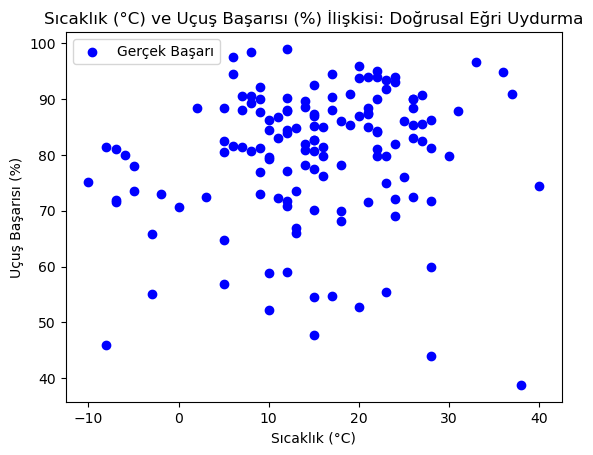

In [131]:
plt.scatter(df['Sıcaklık (°C)'], df['Uçuş Başarısı (%)'], label='Gerçek Başarı', color='blue')
#plt.plot(df['Yaş'], df['Tahmin Edilen Gelir'], label='Tahmin Edilen Gelir (Doğrusal Eğri)', color='red')
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Uçuş Başarısı (%)')
plt.legend()
plt.title('Sıcaklık (°C) ve Uçuş Başarısı (%) İlişkisi: Doğrusal Eğri Uydurma')
plt.show()

In [132]:

# Bağımsız değişkenler (input features) - df datasetinden
X = df[['RÜZGAR HIZI (KM/SAAT)', 'Sıcaklık (°C)', 'Nem Seviyesi (%)', 'Yağmur Olasılığı (%)']]

# Bağımlı değişken (target variable) - df datasetinden
y = df['Uçuş Başarısı (%)']

# Eğitim ve test verisi olarak ayırma (df datasetini model eğitimi için kullanıyoruz)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lineer regresyon modelini oluşturma
model = LinearRegression()

# Modeli eğitim verisiyle eğitme
model.fit(X_train, y_train)

# Test verisiyle tahmin yapma (doğrulama için)
y_pred = model.predict(X_test)

# Modelin doğruluğunu değerlendirme (test verisi için)
mse = mean_squared_error(y_test, y_pred)  # Ortalama kare hata
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred) # Bağımlı değişkenin toplam varyansının yüzde kaçının bağımsız değişkenler tarafından açıklandığını göster

# Sonuçları yazdırma (test verisi)

print("\nR2 Score değeri :", r2)
print("\nOrtalama Kare Hata :", rmse)




# df_real datasetini kullanarak tahmin yapma
# Bağımsız değişkenler (input features) - df datasetinden
X_real = df[['RÜZGAR HIZI (KM/SAAT)', 'Sıcaklık (°C)', 'Nem Seviyesi (%)', 'Yağmur Olasılığı (%)']]

# df datasetindeki her satır için tahmin yap
y_real_pred = model.predict(X_real)

# df_real datasetine tahmin edilen uçuş başarısı sütununu ekleme
df['Tahmin Edilen Uçuş Başarısı (%)'] = y_real_pred



R2 Score değeri : 0.7124248256260406

Ortalama Kare Hata : 8.130654090353255


In [133]:

# Sonuçları yazdırma
print(df[['RÜZGAR HIZI (KM/SAAT)', 'Sıcaklık (°C)', 'Nem Seviyesi (%)', 'Yağmur Olasılığı (%)', 'Tahmin Edilen Uçuş Başarısı (%)']])

df.to_csv('test_regresyon_final.csv', index=False)


     RÜZGAR HIZI (KM/SAAT)  Sıcaklık (°C)  Nem Seviyesi (%)  \
0                15.000000           22.0         21.000000   
1                11.000000           21.0         89.000000   
2                 6.000000            6.0         59.615385   
3                25.000000           12.0         61.000000   
4                17.000000           27.0         71.000000   
..                     ...            ...               ...   
134               7.000000           22.0         54.000000   
135              58.000000           38.0         10.000000   
136              33.000000            0.0         62.000000   
137              24.169355           21.0         66.000000   
138              51.000000           28.0         60.000000   

     Yağmur Olasılığı (%)  Tahmin Edilen Uçuş Başarısı (%)  
0                    27.0                        87.331576  
1                    43.0                        81.708985  
2                    53.0                        79.049824  

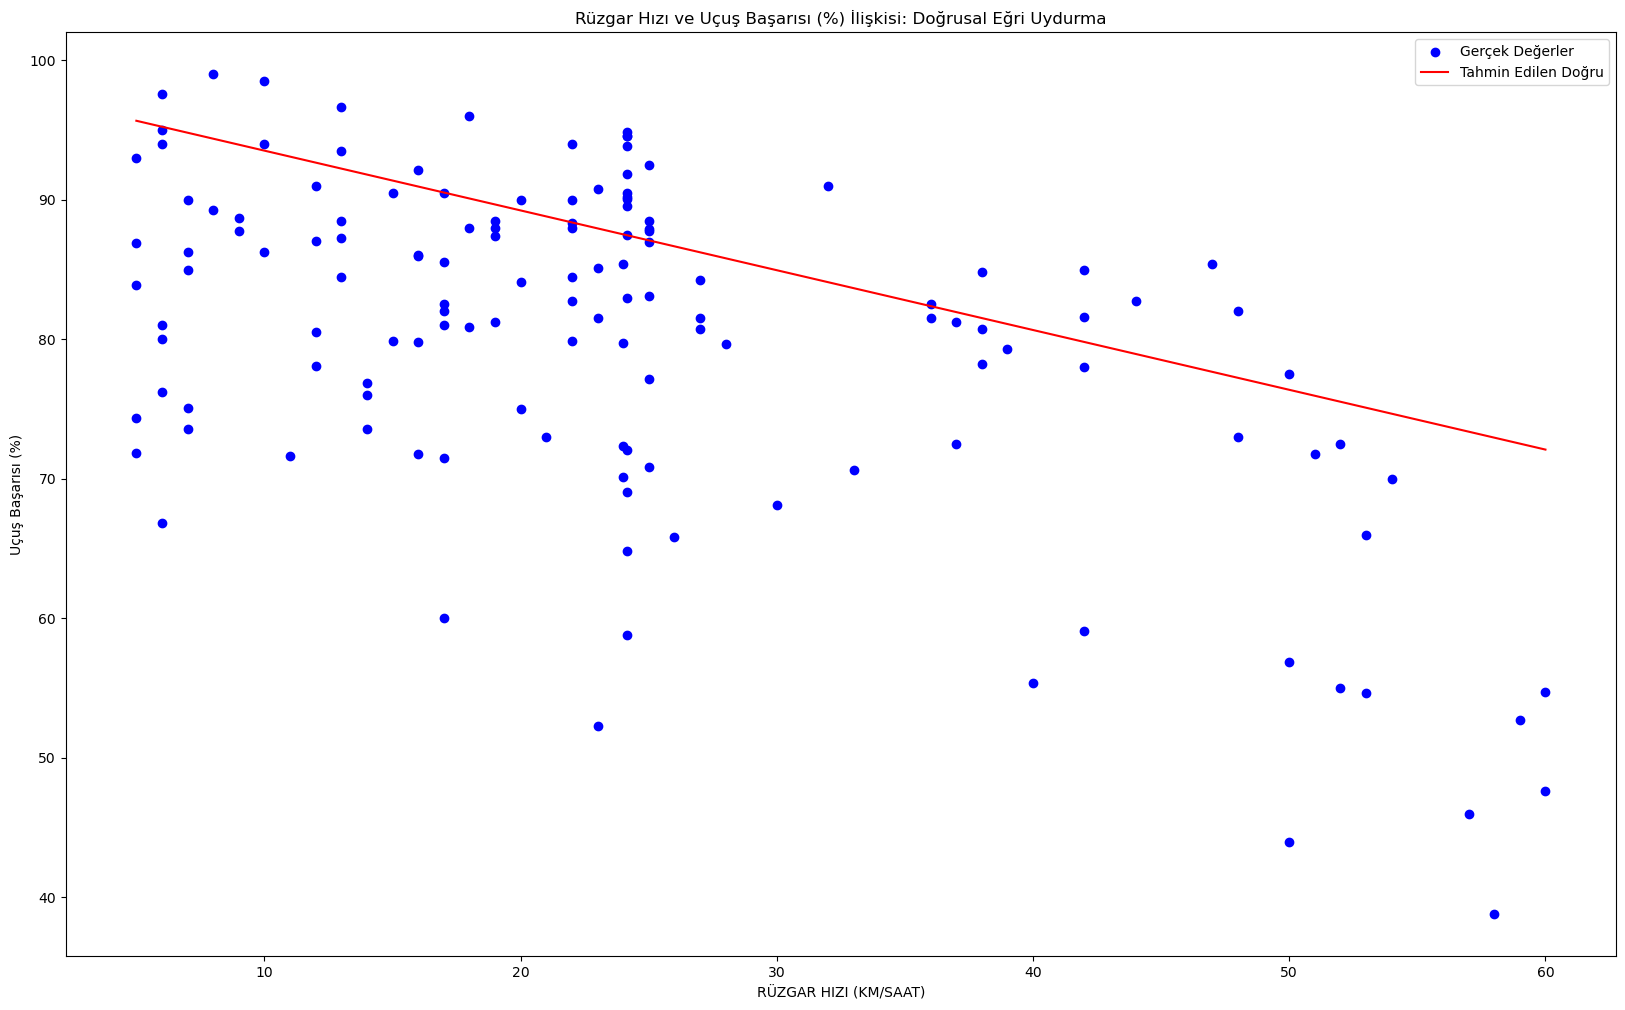

In [156]:
plt.figure(figsize=(20, 12))
# Elde edilen modelin eğimi ve kesişimi
slope = model.coef_[0]  # RÜZGAR HIZI (KM/SAAT) için katsayı
intercept = model.intercept_  # Y ekseni kesişimi

# Rüzgar Hızı (x ekseni) değer aralığını belirle
x_range = np.linspace(df['RÜZGAR HIZI (KM/SAAT)'].min(), df['RÜZGAR HIZI (KM/SAAT)'].max(), 100)

# Doğru üzerindeki y (Uçuş Başarısı) değerlerini hesapla
y_range = slope * x_range + intercept

# Gerçek değerleri çizdir
plt.scatter(df['RÜZGAR HIZI (KM/SAAT)'], df['Uçuş Başarısı (%)'], color='blue', label='Gerçek Değerler')

# Hesaplanan doğruyu çizdir
plt.plot(x_range, y_range, color='red', label='Tahmin Edilen Doğru')

# Grafiği düzenle
plt.xlabel('RÜZGAR HIZI (KM/SAAT)')
plt.ylabel('Uçuş Başarısı (%)')
plt.title('Rüzgar Hızı ve Uçuş Başarısı (%) İlişkisi: Doğrusal Eğri Uydurma')
plt.legend()
plt.show()

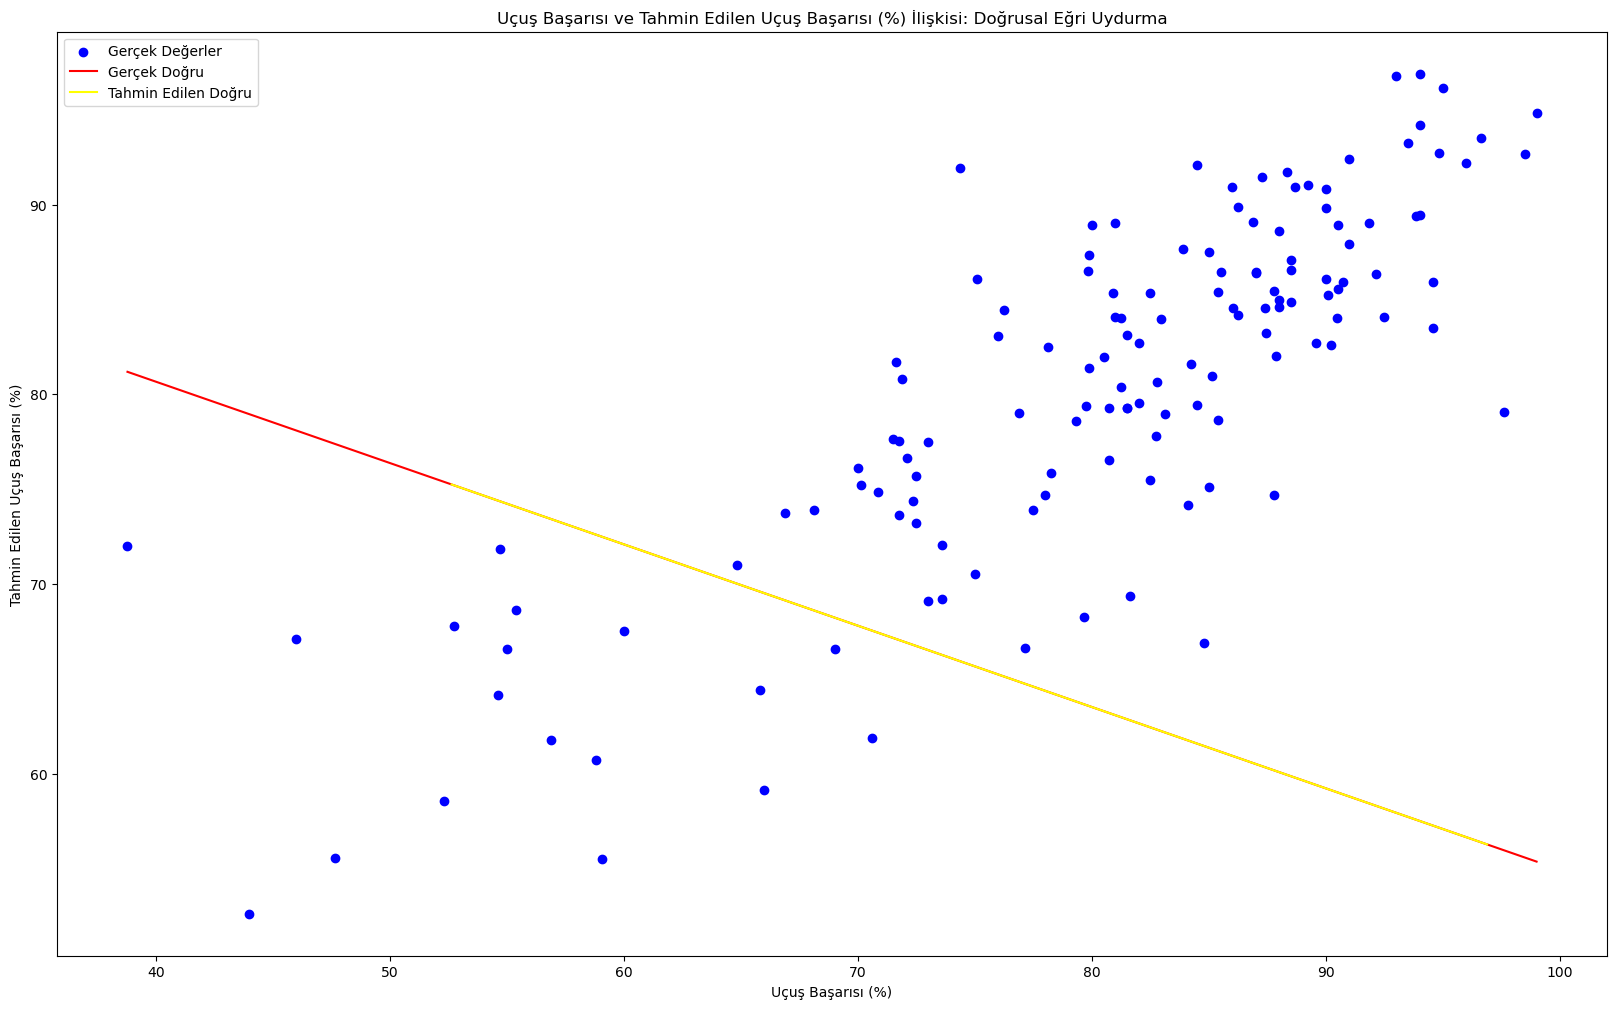

In [160]:
plt.figure(figsize=(20, 12))
# Elde edilen modelin eğimi ve kesişimi
slope = model.coef_[0]  
intercept = model.intercept_  # Y ekseni kesişimi


x_range = np.linspace(df['Uçuş Başarısı (%)'].min(), df['Uçuş Başarısı (%)'].max(), 100)
x2_range = np.linspace(df['Tahmin Edilen Uçuş Başarısı (%)'].min(), df['Tahmin Edilen Uçuş Başarısı (%)'].max(), 100)

y_range = slope * x_range + intercept
y2_range = slope * x2_range + intercept

# Gerçek değerleri çizdir
plt.scatter(df['Uçuş Başarısı (%)'], df['Tahmin Edilen Uçuş Başarısı (%)'], color='blue', label='Gerçek Değerler')

# Hesaplanan doğruyu çizdir
plt.plot(x_range, y_range, color='red', label='Gerçek Doğru')
plt.plot(x2_range, y2_range, color='yellow', label='Tahmin Edilen Doğru')
# Grafiği düzenle
plt.xlabel('Uçuş Başarısı (%)')
plt.ylabel('Tahmin Edilen Uçuş Başarısı (%)')
plt.title('Uçuş Başarısı ve Tahmin Edilen Uçuş Başarısı (%) İlişkisi: Doğrusal Eğri Uydurma')
plt.legend()
plt.show()

R² Skoru: 0.7124248256260406
Ortalama Kare Hata (RMSE): 8.130654090353255


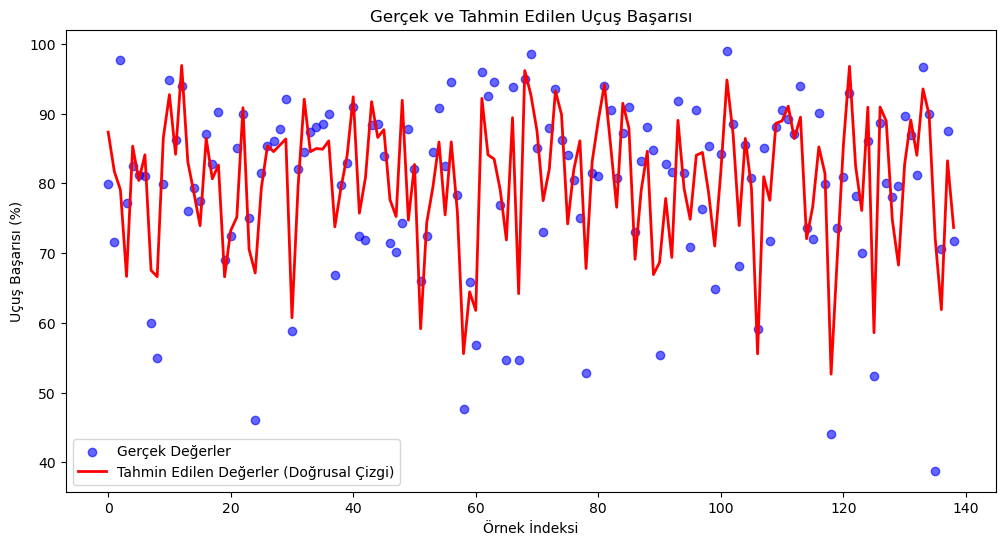

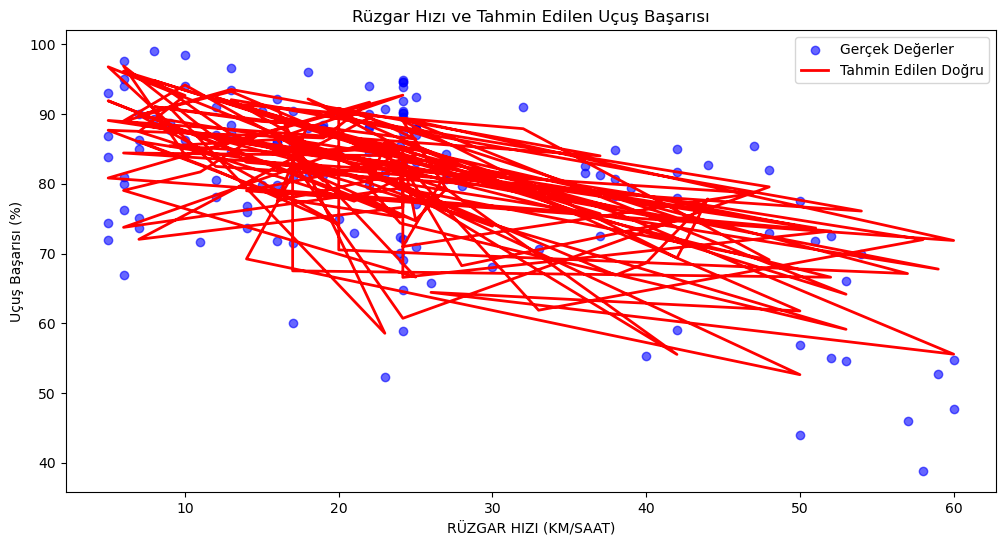

In [136]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt

# Verisetini yükle
df = pd.read_csv('test_regresyon.csv', encoding='utf-8')

# Bağımsız ve bağımlı değişkenler
X = df[['RÜZGAR HIZI (KM/SAAT)', 'Sıcaklık (°C)', 'Nem Seviyesi (%)', 'Yağmur Olasılığı (%)']]
y = df['Uçuş Başarısı (%)']

# Eğitim ve test verisi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model oluştur ve eğit
model = LinearRegression()
model.fit(X_train, y_train)

# Tahmin yap
y_pred = model.predict(X_test)

# Model değerlendirmesi
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R² Skoru: {r2}")
print(f"Ortalama Kare Hata (RMSE): {rmse}")

# Tüm veriseti üzerinde tahmin yap
df['Tahmin Edilen Uçuş Başarısı (%)'] = model.predict(X)

# Gerçek ve tahmin edilen değerlerin karşılaştırması
plt.figure(figsize=(12, 6))
plt.scatter(df.index, df['Uçuş Başarısı (%)'], label='Gerçek Değerler', color='blue', alpha=0.6)
plt.plot(df.index, df['Tahmin Edilen Uçuş Başarısı (%)'], label='Tahmin Edilen Değerler (Doğrusal Çizgi)', color='red', linewidth=2)
plt.xlabel('Örnek İndeksi')
plt.ylabel('Uçuş Başarısı (%)')
plt.title('Gerçek ve Tahmin Edilen Uçuş Başarısı')
plt.legend()
plt.show()

# Tahmin edilen uçuş başarısı ve bir bağımsız değişken ilişkisi (örneğin: RÜZGAR HIZI)
plt.figure(figsize=(12, 6))
plt.scatter(df['RÜZGAR HIZI (KM/SAAT)'], df['Uçuş Başarısı (%)'], label='Gerçek Değerler', color='blue', alpha=0.6)
plt.plot(df['RÜZGAR HIZI (KM/SAAT)'], df['Tahmin Edilen Uçuş Başarısı (%)'], label='Tahmin Edilen Doğru', color='red', linewidth=2)
plt.xlabel('RÜZGAR HIZI (KM/SAAT)')
plt.ylabel('Uçuş Başarısı (%)')
plt.title('Rüzgar Hızı ve Tahmin Edilen Uçuş Başarısı')
plt.legend()
plt.show()

# Sonuçları kaydetme
df.to_csv('test_regresyon_final.csv', index=False)
